# 분류 요약본

## 1. 분류란?

### 지도학습: 회귀와 분류의 차이

**1) 회귀**
- 주어진 데이터(X)를 기반으로 정답(Y)를 잘 맞추는(fit)하는 함수(function)
- 데이터가 연속형 변수를 예측하기 위해 사용될 때

**2) 분류**
- 기존 데이터가 어떤 레이블에 속하는지 패턴을 알고리즘으로 인지한 뒤에 새롭게 관측된 데이터에 대한 레이블을 판별하는 것
- 데이터가 범주형 변수를 예측하기 위해 사용될 때

### 이진 분류와 다중 분류

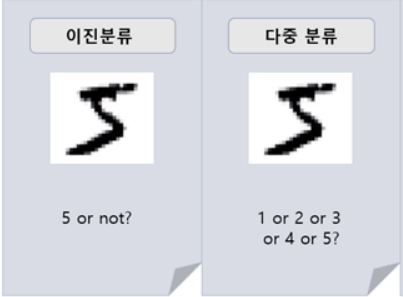

**1) 이진 분류(Binary Classification)**
- 예측하고자 하는 변수 어떤 기준에 대하여 참(True) 또는 거짓(False)의 값만을 가질 때

**2) 다중 분류(Multiclass Classification)**
- 예측하고자 하는 변수가 가질 수 있는 값이 3개 이상일 때

## 2. 분류 모델

### 2-1. 로지스틱 회귀

- 이진 분류 문제를 푸는 대표적인 알고리즘으로, 샘플이 특정 클래스에 속할 확률을 추정하여 기준치에 따라 분류
- 일반적인 선형 회귀는 연속적인 값을 예측하는 데 사용되지만, 분류 문제에서는 예측값이 0과 1 사이의 값을 가져야 함
- 따라서 독립 변수의 선형 조합 wx+b에 **로지스틱 함수(시그모이드 함수)** 를 적용하여 출력값을 0~1 사이로 변환

**1) 시그모이드 함수**

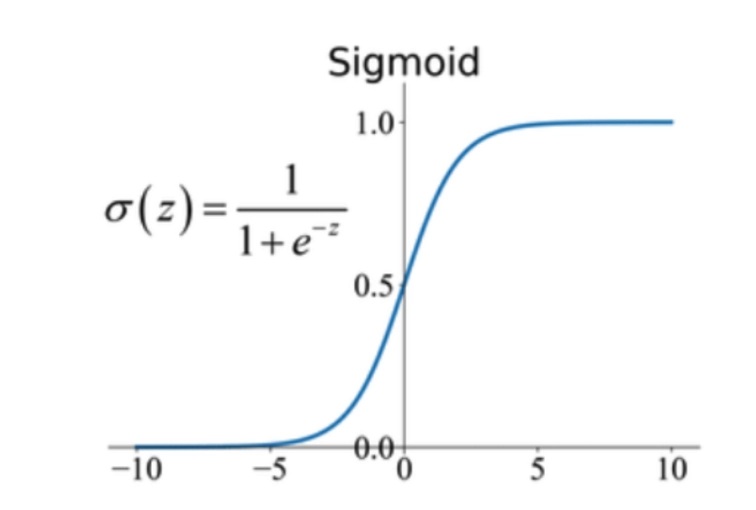

- (개념) 출력이 0과 1 사이의 값을 가지면서 S자 형태로 그려지는 함수
- (특징) 입력값이 커지면 출력값은 1에 수렴하고, 입력값이 작아지면 0에 수렴
- (특징) 입력값이 양 끝에 위치할수록 출력값의 변화가 작고, 중간값 근처에서는 급격히 변화

**2) 시그모이드 함수의 가중치**

**case 1. 가중치 w의 변화에 따른 그래프 변화 (그래프의 기울기 변화)**

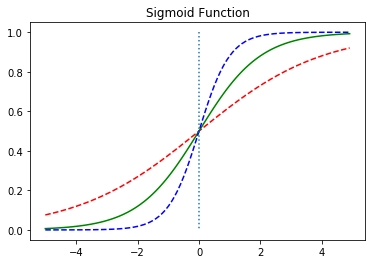
*각각 w=0.5, w=1.0, w=2.0*
- w가 커질수록 시그모이드 함수가 중간값 근처에서 더 급격하게 변화

**case 2. 가중치 b의 변화에 따른 그래프 변화 (그래프의 위치 변화)**

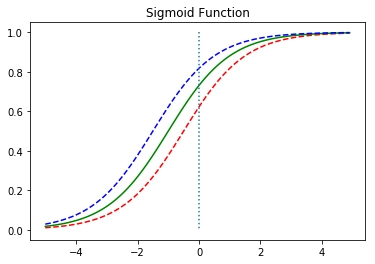
*각각 b=0.5, b=1.0, b=1.5*
- b가 변화하면 시그모이드 그래프의 위치가 좌우로 이동

### 2-2. 의사결정나무

- 조건에 따라 데이터를 분류하며, 최종적으로 데이터가 순수한 label의 집합으로 구성될 때까지 분류를 반복하는 분석 방법

**1) 의사결정나무의 구성 요소**

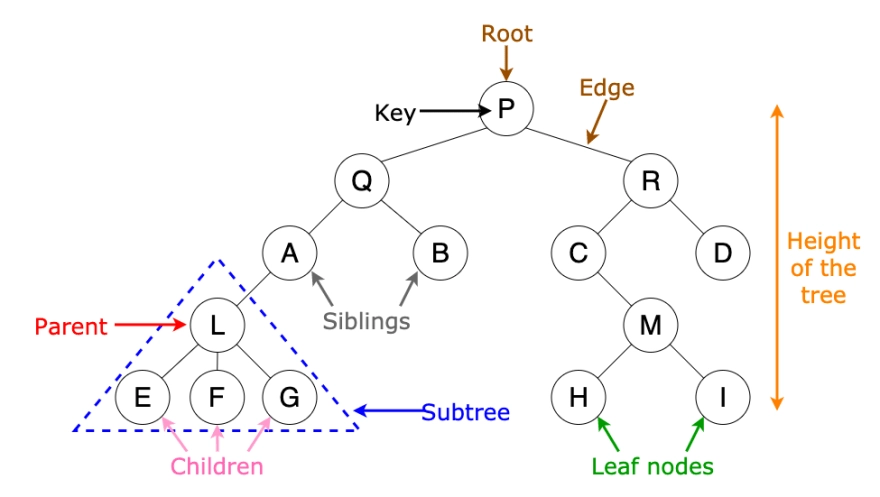

- Root Node: 가장 상위에 위치한 노드
- Parent Node: 주어진 노드의 상위에 있는 노드
- Child Node: 하나의 노드로부터 분리된 2개 이상의 노드
- Binary Tree(이진 트리): children이 최대 2개인 Tree
- Leaf Nodes: 자식마디가 없는 노드로, 모델에서 label에 해당
- Edge: Parent node와 Child node를 연결하는 연결선
- Height: 특정 노드에서 가장 멀리 있는 leaf node까지의 경로에 있는 edge 개수
- Depth: Root node에서 특정 노드에 도달하기 위한 edge의 수

**2) CART 알고리즘**
- 데이터셋을 임계값을 기준으로 두 개의 child로 나누는 알고리즘
- 불순도(지니 계수)가 낮아지는 방향으로 임계값을 결정

   - 불순도란 분류하려는 데이터 집합에서 서로 다른 클래스(범주)가 섞여 있는 정도를 의미 
   - CART 알고리즘에서는 불순도를 확인하기 위해 지니 지수를 사용

① 임계값 설정

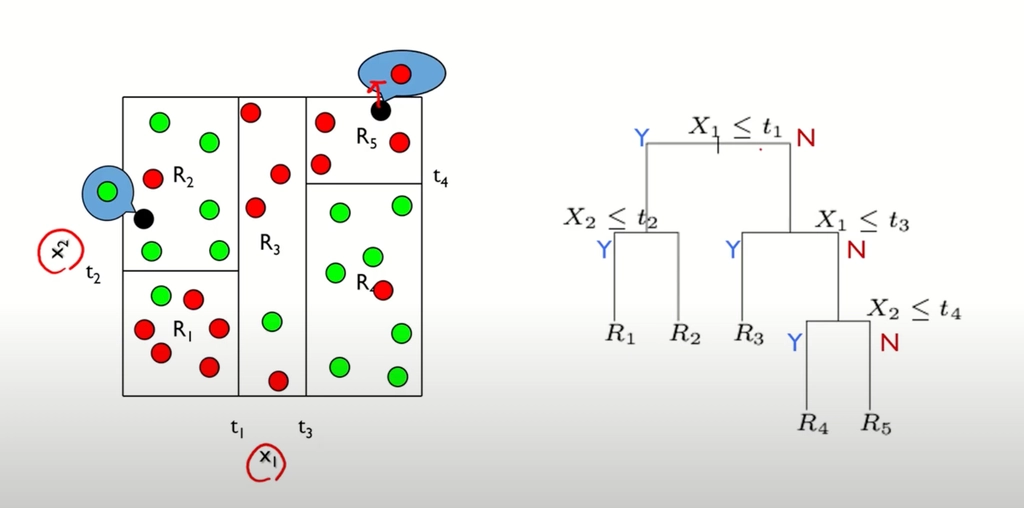
- 각 특성에 대해 임계값을 기준으로 데이터를 두 그룹으로 나눔

② 불순도 감소


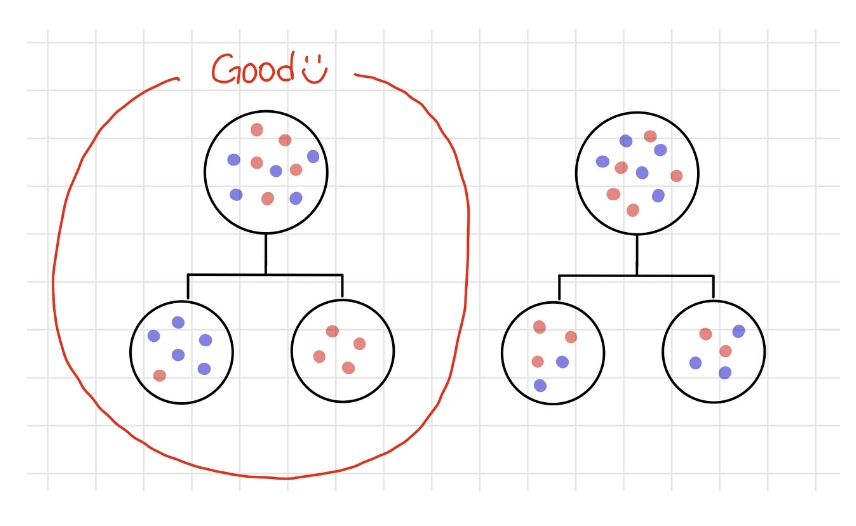
- 여러 분류 기준 중 현재 집단에 서로 다른 객체들이 얼마나 섞여 있는지를 확인하고, 불순도가 낮아지는 쪽으로 가지를 형성


> 결과적으로 동일한 객체들로만 잘 모아지게 하는 분류 기준을 선택

**3) 학습 시 고려 사항**

- 모수(Hyperparameter) 설정

| Hyperparameter | 의미 |
|---|---|
| min_samples_split | 분할되기 위해 노드가 가져야 하는 최소 샘플(데이터) 수 |
| min_samples_leaf | 리프 노드가 가지고 있어야 하는 최소 샘플 수 |
| min_weight_fraction_leaf | min_samples_leaf와 같지만 가중치가 부여된 전체 샘플 수에서의 비율 |
| max_leaf_nodes | 리프 노드의 최대 개수 |
| max_features | 각 노드에서 분할에 사용할 특성의 최대 수 |

- 시각화: 분류가 잘 이루어졌는지 확인
- Pruning: 일부 노드를 제거하여 일반화 성능을 높임

### 2-3. SVM

- 개념
   - 클래스를 분류할 수 있는 다양한 경계선 중 최적의 라인을 찾아내는 알고리즘
   - 데이터를 분리하는 초평면(Hyperplane) 중에서 데이터들과 가장 거리가 먼 초평면을 선택하여 분리하는 지도학습 기반의 이진 선형 분류 모델

- 특징
   - 명확하게 분류할 수 있는 데이터 집단에서 뛰어난 성능을 보이며, 고차원 공간(다수의 feature)에서도 효과적으로 사용 가능
   - 패턴 인식, 이미지 분석, 바이오인포매틱스 등 다양한 머신러닝 응용 분야에서 활용

**1) SVM의 구성**

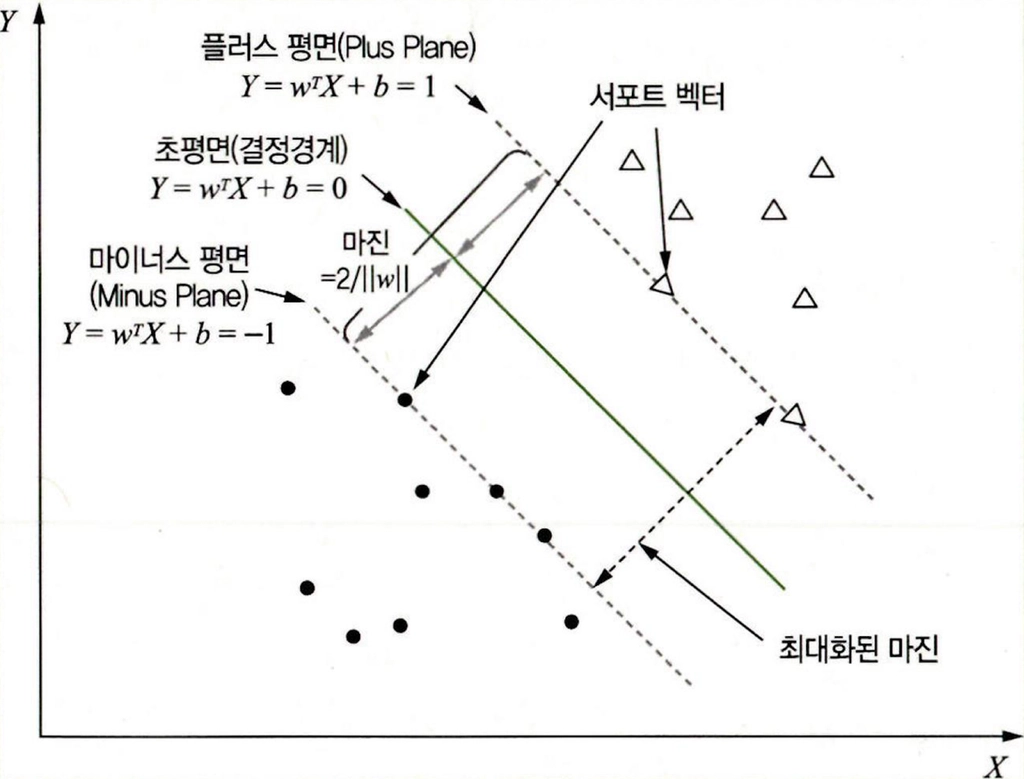

- Support Vector(서포트 벡터): 데이터 중에서 결정 경계와 가장 가까이에 있는 데이터들의 집합
- Decision Boundary(결정 경계): 데이터 분류의 기준이 되는 경계
- Margin(마진): 결정 경계에서 서포트 벡터까지의 거리(여유 공간)
- Hyperplane(초평면): n차원 공간의 n-1차원 평면
- Slack Variables(슬랙 변수/여유 변수): 완벽한 분리가 불가능할 때 분류를 위해 허용된 오차에 대한 변수

**2) 최적의 선을 찾는 방법**

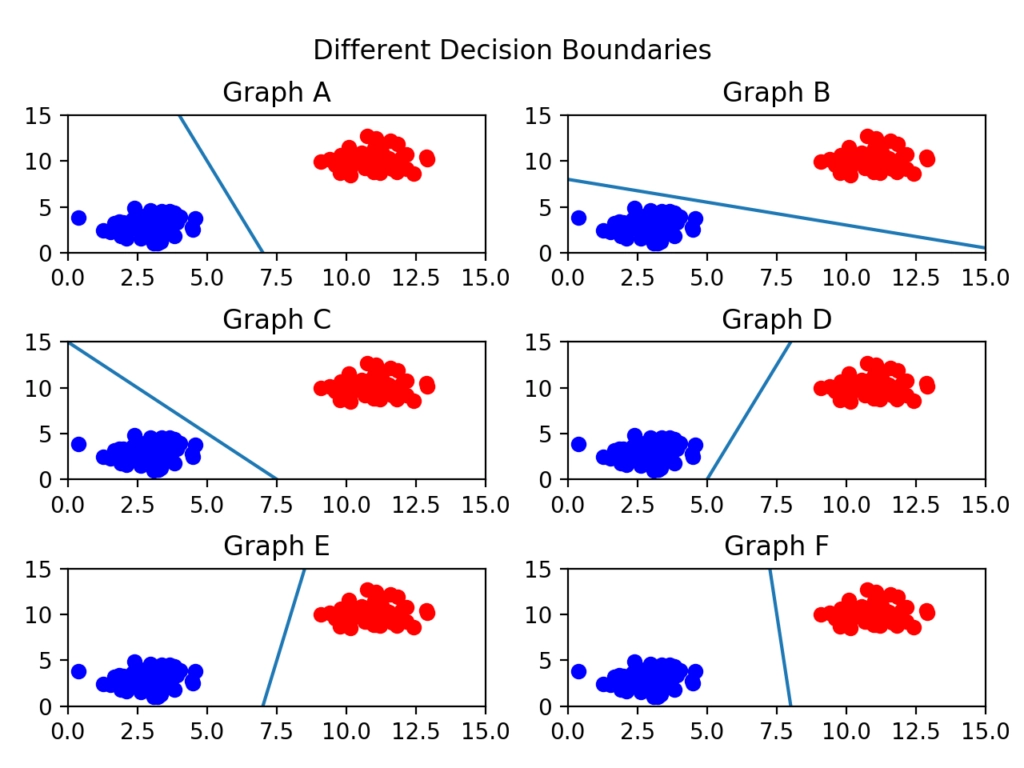

- 데이터로부터 가장 멀리 떨어져 있는 결정 경계를 선택
- 즉, Margin(거리)이 가장 큰 경우를 선택함으로써 최적의 선을 찾음

**3) 장단점**
| 장점 | 단점 |
|---|---|
| 서포트 벡터만을 이용해서 결정 경계를 생성하므로 데이터가 적을 때 효과적 | 데이터 전처리 과정이 중요 |
| 새로운 데이터가 입력되면 전체 데이터 포인트와의 거리를 계산하지 않고 서포트 벡터와의 거리만 계산하면 되기 때문에 연산량 최소화 | 데이터가 많아질수록 최적화를 위한 평가 과정이 많아져서 속도가 느림 |
| 정확성이 뛰어나며, 비선형 모델 분류 가능 (커널 사용 시) |  |
| 마진을 최대화하는 방식이 규제 역할을 하고 노이즈의 영향이 적음 |  |

### 2-4. KNN

- (개념) 비슷한 특성을 가진 데이터끼리 서로 가까이 있다는 점을 이용한 분류 알고리즘
- (특징) 새로운 데이터가 주어지면 거리가 가까운 K개의 다른 데이터 레이블을 참조하여 분류
- (특징) 학습이 필요하지 않아 별도의 모델을 만들지 않고 데이터를 이용하여 새로운 데이터가 들어왔을 때 즉석에서 주변 데이터를 이용해 분류

**1) KNN 알고리즘 계산 순서**

① 데이터 준비
- 미리 학습하는 과정이 없기 때문에 데이터 준비
- 각 데이터는 특징 벡터와 레이블(class)로 이루어짐

② K값 설정
- K는 가장 가까운 이웃의 개수를 의미, 보통 홀수 개 설정

③ 거리 계산
- 새로운 데이터가 주어지면 해당 데이터와 기존 모든 데이터 간의 거리를 계산
- 보통 유클리드 거리, 맨해튼 거리 등을 사용

④ 가장 가까운 K개의 이웃 선택
- 계산된 거리 중 가장 작은 거리 값을 가진 K개의 데이터를 선택

⑤ 분류
- K개의 이웃 중 가장 많이 등장하는 클래스가 예측 결과가 됨(다수결의 원칙)

**2) 장단점**
| 장점 | 단점 |
|---|---|
| 범주를 나눈 기준을 알지 못해도 데이터를 분류할 수 있음 | 다른 분류 모형과 달리 테스트 데이터의 개수에 따라 시간이 오래 걸림 |
| 입력 데이터만 주어지면 바로 예측값을 구할 수 있어서 다른 분류 모형과는 달리 학습 과정이 필요 없음 | 학습 데이터 모두를 거리 계산에 사용하기 때문에 학습 데이터의 양도 계산 시간에 영향을 미침 |
| 이해가 쉽고, 구현이 간단 | K의 값 결정이 어려움 |
| 추가된 데이터의 처리가 용이 | 수치형 데이터가 아니면 유사도를 정의하기 어려움 |
| 훈련 데이터를 요약하거나 일반화된 모델로 만들지 않고, 원본 데이터 전체를 그대로 저장 | 데이터 내 이상치가 존재하면 분류 성능에 큰 영향을 받음 |

## 3. 분류 평가 지표

### 3-1. 혼동 행렬
- 혼동 행렬은 분류 모델의 예측 결과를 정확한 예측과 잘못된 예측으로 구분하여 나타낸 표(행렬)
- 예측 성공 여부 True/False와 예측값 Positive/Negative의 조합에 따라 총 4가지로 구분

| 구분 | 의미 |
|---|---|
| **TP (True Positive)** | 실제 참 → 참으로 예측 |
| **TN (True Negative)** | 실제 거짓 → 거짓으로 예측 |
| **FP (False Positive)** | 실제 거짓 → 참으로 예측 |
| **FN (False Negative)** | 실제 참 → 거짓으로 예측 |

혼동 행렬을 이용한 분류 모델 평가 지표

**1) 정확도 (Accuracy)**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- 모든 가능한 예측 중 참인 비율


**2) 정밀도 (precision)**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- 참이라고 예측한 경우 실제 참의 비율


**3) 재현도 (recall)**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- 실제로 참인 경우 중 참으로 예측하는 비율

> Threshold ↓ → Recall ↑, Precision ↓ 

> Threshold ↑ → Recall ↓, Precision ↑

### 3-2. F1-Score


- F1-Score = Precision(정밀도)과 Recall(재현율)의 조화평균

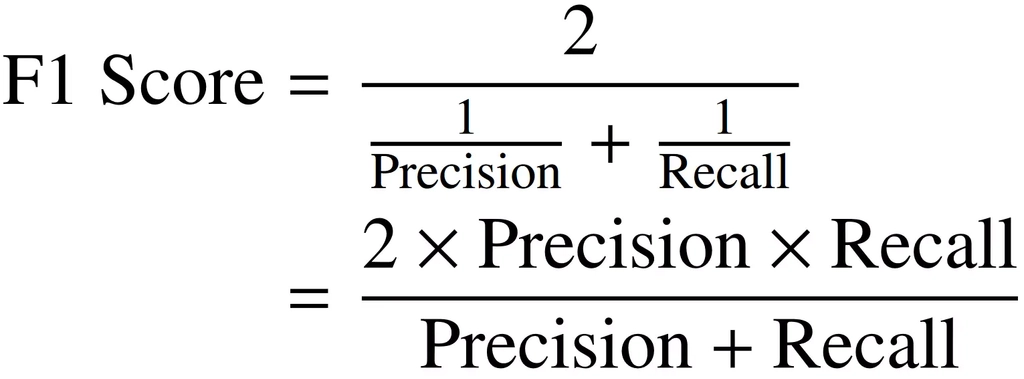

### 3-3. ROC / AUC

**1) ROC Curve**

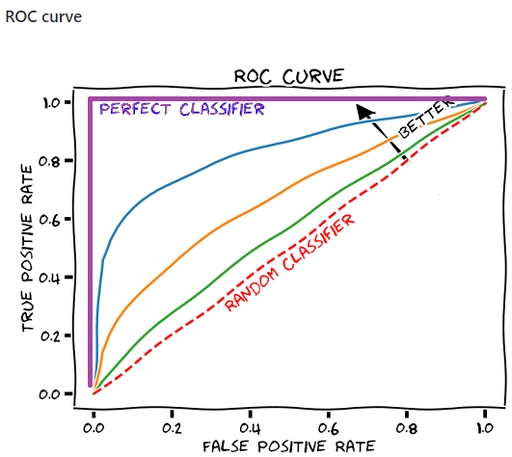

- 얼마나 분류가 잘 되었는가를 보여주는 그래프
- True Positive Rate (TPR): 참인 것들 중에 참이라고 예측한 비율 (=Recall)
- False Positive Rate (FPR): 거짓인 것들 중에 참이라고 잘못 예측한 비율 

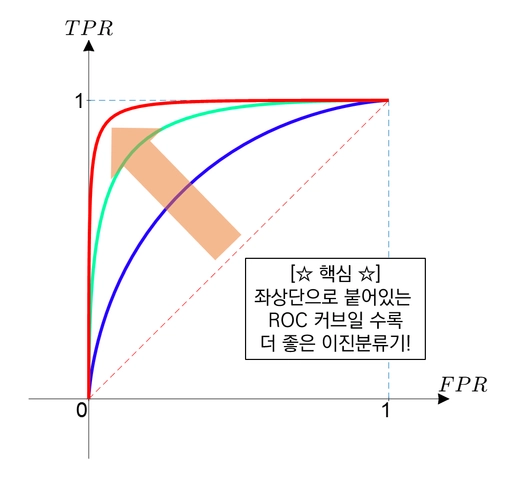

- Positive는 최대한 많이 발견 → TPR 높게
- Negative를 Positive로 잘못 판단하는 것은 최소화 → FPR 낮게
> 좌측 상단으로 붙을수록 분류 성능이 좋다고 해석

**2) AUC**

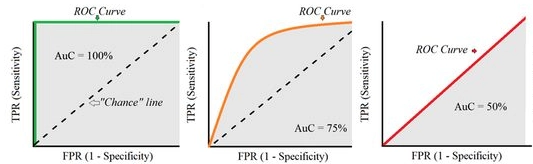

- AUC Curve: ROC와 x축 사이의 면적(적분값)
- 0.5에서 1사이의 값을 가지며, 1에 가까울수록 분류 성능이 좋은 것에 해당

## 4. 하이퍼파라미터 최적화

- Hyperparameter: 모델 학습 과정에 반영되는 값으로, 학습 시작 전에 사용자가 직접 설정하는 변수
- Hyperparameter Optimization: Tuning을 거쳐 적절한 하이퍼파라미터를 찾음으로써 Model 성능을 향상시키는 것

하이퍼파라미터 최적화 방법

**1) Grid Search**

- 정해진 범위에서 Hyperparameter를 모두 순회하며 가장 좋은 성능을 내는 값을 찾는 기법

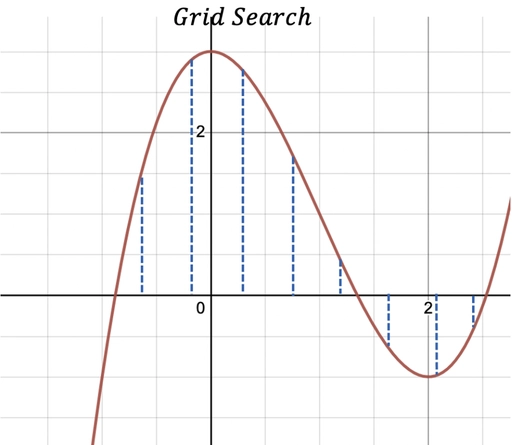


- (장점) 범위가 넓고 step이 작을수록 꼼꼼하게 전 범위를 탐색하니 최적해를 정확히 찾을 수 있음
- (단점) 시간이 오래 걸림
- (적용) 넓은 범위, 큰 step을 활용해 범위를 좁힘


**2) Random Search**

- 정해진 범위에서 Hyperparameter를 무작위로 탐색해 가장 좋은 성능을 내는 값을 찾는 기법

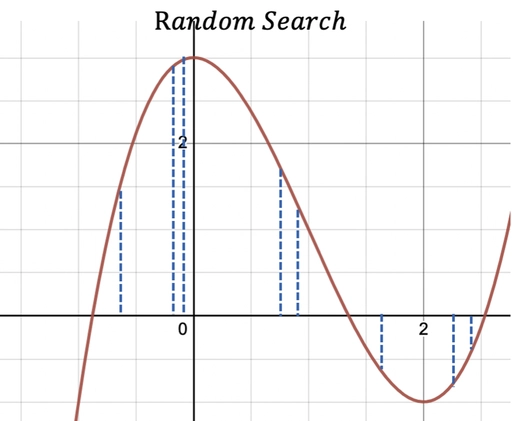

- (장점) 속도가 Grid Search보다 빠름
- (단점) 무작위라는 한계 때문에 정확도가 떨어져 Grid Search나 Bayesian Optimization에 비해 사용 빈도가 적음


**3) Bayesian Optimization**

- 사전 정보를 바탕으로 최적 Hyperparameter 값을 확률적으로 추정하며 탐색하는 기법

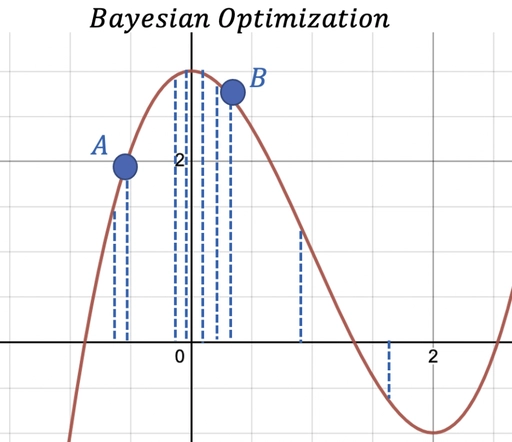

- (특징) 여러 개의 하이퍼 파라미터들에 대해서 Acquisition Function을 적용했을 때 가장 큰 값이 나올 확률이 높은 지점을 찾아냄